In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("inventory.csv")

In [3]:
# Step 1. DATA CLEANING

In [4]:
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


In [5]:
df.shape

(73100, 15)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                73100 non-null  object 
 1   Store ID            73100 non-null  object 
 2   Product ID          73100 non-null  object 
 3   Category            73100 non-null  object 
 4   Region              73100 non-null  object 
 5   Inventory Level     73100 non-null  int64  
 6   Units Sold          73100 non-null  int64  
 7   Units Ordered       73100 non-null  int64  
 8   Demand Forecast     73100 non-null  float64
 9   Price               73100 non-null  float64
 10  Discount            73100 non-null  int64  
 11  Weather Condition   73100 non-null  object 
 12  Holiday/Promotion   73100 non-null  int64  
 13  Competitor Pricing  73100 non-null  float64
 14  Seasonality         73100 non-null  object 
dtypes: float64(3), int64(5), object(7)
memory usage: 8.4+

In [7]:
#The dataset contained 73,100 retail inventory records with 15 variables including product information, inventory levels, sales history, pricing factors, promotions, weather conditions, and seasonality indicators.

In [8]:
#Check Missing Values

In [9]:
df.isnull().sum()

Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Demand Forecast       0
Price                 0
Discount              0
Weather Condition     0
Holiday/Promotion     0
Competitor Pricing    0
Seasonality           0
dtype: int64

In [10]:
# Check Duplicate Records

In [11]:
df.duplicated().sum()

0

In [12]:
# Convert Date Column

In [13]:
df["Date"] = pd.to_datetime(df["Date"])

In [14]:
# Check

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                73100 non-null  datetime64[ns]
 1   Store ID            73100 non-null  object        
 2   Product ID          73100 non-null  object        
 3   Category            73100 non-null  object        
 4   Region              73100 non-null  object        
 5   Inventory Level     73100 non-null  int64         
 6   Units Sold          73100 non-null  int64         
 7   Units Ordered       73100 non-null  int64         
 8   Demand Forecast     73100 non-null  float64       
 9   Price               73100 non-null  float64       
 10  Discount            73100 non-null  int64         
 11  Weather Condition   73100 non-null  object        
 12  Holiday/Promotion   73100 non-null  int64         
 13  Competitor Pricing  73100 non-null  float64   

In [16]:
# datetime64[ns] date column from object to datetime

In [17]:
# Check Invalid Values in inventory level

In [18]:
(df["Inventory Level"] < 0).sum()

0

In [19]:
# Check Invalid Values in Units sold

In [20]:
(df["Units Sold"] < 0).sum()

0

In [21]:
# Check Invalid Values in Price

In [22]:
(df["Price"] < 0).sum()

0

In [23]:
# Check Unique Values for typo and overall understanding of product sold and business

In [24]:
df["Category"].unique()

array(['Groceries', 'Toys', 'Electronics', 'Furniture', 'Clothing'],
      dtype=object)

In [25]:
df["Region"].unique()

array(['North', 'South', 'West', 'East'], dtype=object)

In [26]:
df["Seasonality"].unique()

array(['Autumn', 'Summer', 'Winter', 'Spring'], dtype=object)

In [27]:
# Check for unrealistic values 

In [28]:
# In inventory 

In [29]:
df["Inventory Level"].describe()

count    73100.000000
mean       274.469877
std        129.949514
min         50.000000
25%        162.000000
50%        273.000000
75%        387.000000
max        500.000000
Name: Inventory Level, dtype: float64

In [30]:
# Inventory levels ranged from 50 to 500 units, with an average inventory level of approximately 274 units per product-store-date observation. No negative or unrealistic inventory values were identified, indicating that the dataset was suitable for inventory performance analysis.

In [31]:
# Units sold check

In [32]:
df["Units Sold"].describe()

count    73100.000000
mean       136.464870
std        108.919406
min          0.000000
25%         49.000000
50%        107.000000
75%        203.000000
max        499.000000
Name: Units Sold, dtype: float64

In [33]:
# Looks good 

In [34]:
# Check units ordered

In [35]:
df["Units Ordered"].describe()

count    73100.000000
mean       110.004473
std         52.277448
min         20.000000
25%         65.000000
50%        110.000000
75%        155.000000
max        200.000000
Name: Units Ordered, dtype: float64

In [36]:
# check price

In [37]:
df["Price"].describe()

count    73100.000000
mean        55.135108
std         26.021945
min         10.000000
25%         32.650000
50%         55.050000
75%         77.860000
max        100.000000
Name: Price, dtype: float64

In [38]:
# Looks good

In [39]:
# Creating the Year Month Week and  Day column for more clarity and demand forecasting

In [40]:
df["Year"] = df["Date"].dt.year

In [41]:
df["Month"] = df["Date"].dt.month

In [42]:
df["Day_of_Week"] = df["Date"].dt.day_name()

In [43]:
df["Week"] = df["Date"].dt.isocalendar().week

In [44]:
# check if columns appear

In [45]:
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality,Year,Month,Day_of_Week,Week
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn,2022,1,Saturday,52
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn,2022,1,Saturday,52
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer,2022,1,Saturday,52
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn,2022,1,Saturday,52
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer,2022,1,Saturday,52


In [46]:
# Step 2: EXPLORATORY DATA ANALYSIS (EDA)

In [47]:
# Basic Dataset Overview

In [48]:
# Total Products

In [49]:
df["Product ID"].nunique()

20

In [50]:
# total Stores 

In [51]:
df["Store ID"].nunique()

5

In [52]:
# Total Units Sold 

In [53]:
df["Units Sold"].sum()

9975582

In [54]:
# Total Revenue column (Units Sold × Price)

In [55]:
df["Revenue"] = df["Units Sold"] * df["Price"]

In [56]:
df["Revenue"].sum()

550228884.91

In [57]:
# Average Inventory Level 

In [58]:
df["Inventory Level"].mean()

274.46987688098494

In [59]:
# Sales Analysis 

In [60]:
# 1. categories that generate the most sales

In [61]:
category_sales = df.groupby("Category")["Units Sold"].sum().sort_values(ascending=False)

category_sales

Category
Furniture      2025017
Groceries      2000482
Clothing       1999166
Toys           1990485
Electronics    1960432
Name: Units Sold, dtype: int64

In [62]:
# Visualization chart 

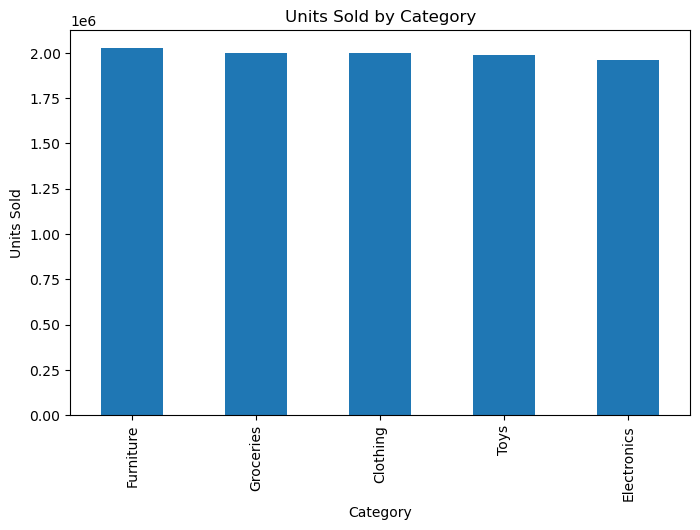

In [63]:
plt.figure(figsize=(8,5))

category_sales.plot(kind="bar")

plt.title("Units Sold by Category")
plt.xlabel("Category")
plt.ylabel("Units Sold")

plt.show()

In [64]:
# Each category sells approximately equally

In [65]:
# 2. Revenue by Category

In [66]:
category_revenue = df.groupby("Category")["Revenue"].sum().sort_values(ascending=False)

category_revenue

Category
Furniture      1.115118e+08
Groceries      1.109845e+08
Clothing       1.096510e+08
Toys           1.096424e+08
Electronics    1.084391e+08
Name: Revenue, dtype: float64

In [67]:
# chart for revenue by category

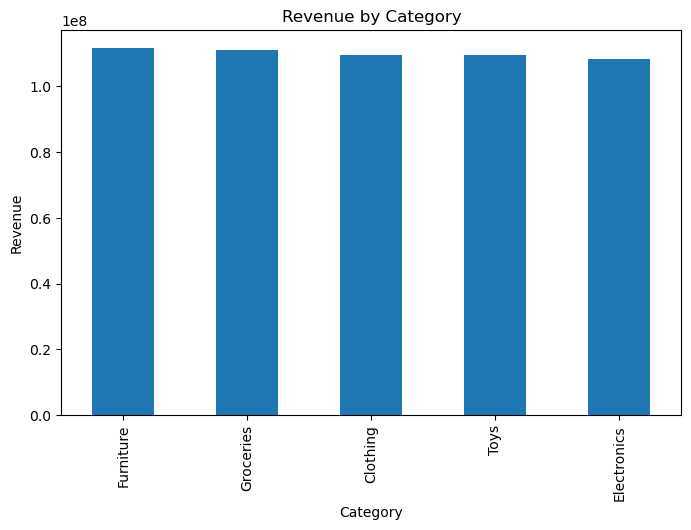

In [68]:
plt.figure(figsize=(8,5))

category_revenue.plot(kind="bar")

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")

plt.show()

In [69]:
# Each category has similar revenues

In [70]:
# 3. Top selling products

In [71]:
top_products = df.groupby("Product ID")["Units Sold"].sum().sort_values(ascending=False).head(10)

top_products

Product ID
P0016    508472
P0020    507708
P0014    507622
P0015    507283
P0005    503648
P0009    502086
P0013    500619
P0017    500510
P0011    499362
P0007    499321
Name: Units Sold, dtype: int64

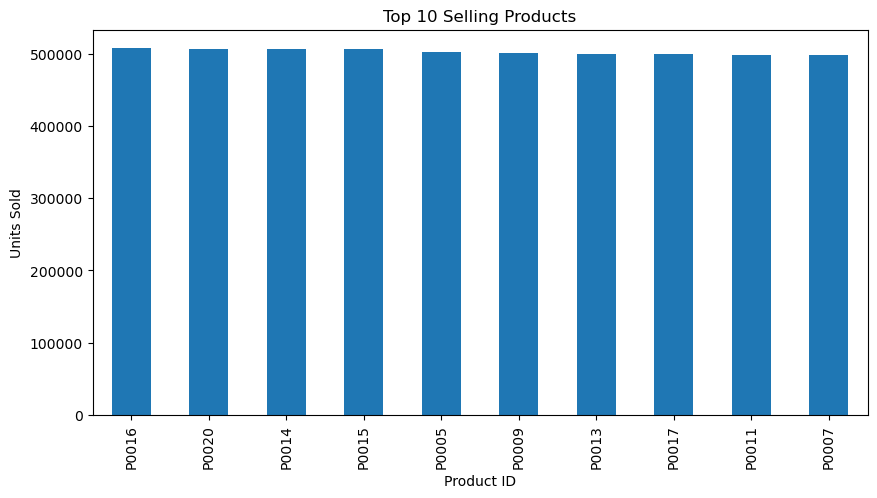

In [72]:
plt.figure(figsize=(10,5))

top_products.plot(kind="bar")

plt.title("Top 10 Selling Products")
plt.xlabel("Product ID")
plt.ylabel("Units Sold")

plt.show()

In [73]:
# Product 16 is the top selling product with 508472

In [74]:
# 4. Monthly Demand Trend

In [75]:
monthly_sales = df.groupby("Month")["Units Sold"].sum()

monthly_sales

Month
1     856590
2     776220
3     842595
4     808457
5     833472
6     821150
7     864547
8     841417
9     816971
10    852509
11    830661
12    830993
Name: Units Sold, dtype: int64

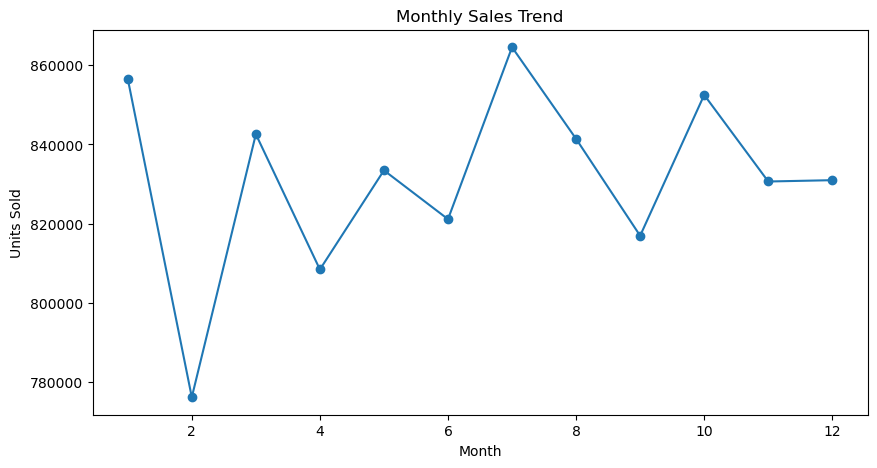

In [76]:
plt.figure(figsize=(10,5))

monthly_sales.plot(kind="line", marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Units Sold")

plt.show()

In [77]:
# Monthly Sales trend are very close each months but Y axis is too small which can be deceiving so Y axis modification and values spaces increase

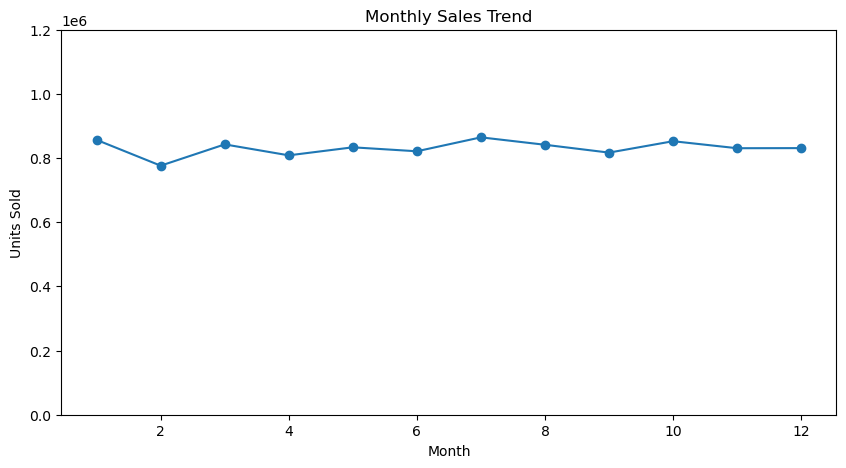

In [78]:
plt.figure(figsize=(10,5))

monthly_sales.plot(kind="line", marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Units Sold")

plt.yticks(range(0, 1200001, 200000))

plt.show()

In [79]:
# Y axis in millions for dashboard 

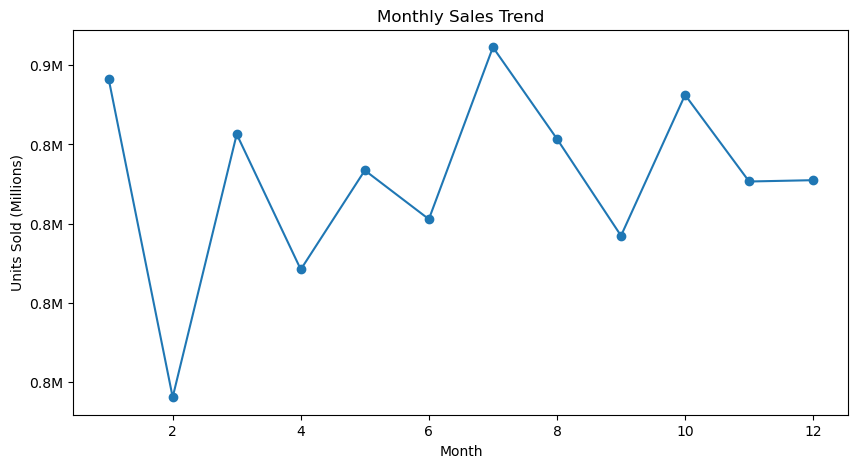

In [80]:
plt.figure(figsize=(10,5))

monthly_sales.plot(kind="line", marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Units Sold (Millions)")

# Convert Y-axis values to millions
plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
)

plt.show()

In [81]:
# Analysis : slight decrease in february but pretty much the same

In [82]:
# break, saving dataset

In [83]:
df.to_csv("clean_inventory.csv", index=False)

In [84]:
df.shape

(73100, 20)

In [85]:
# 5. Inventory Analysis

In [86]:
# categories with the highest average inventory

In [87]:
inventory_by_category = (
    df.groupby("Category")["Inventory Level"]
    .mean()
    .sort_values(ascending=False)
)

inventory_by_category

Category
Furniture      275.816246
Groceries      275.755595
Clothing       274.597771
Toys           273.646862
Electronics    272.514427
Name: Inventory Level, dtype: float64

In [88]:
# chart 

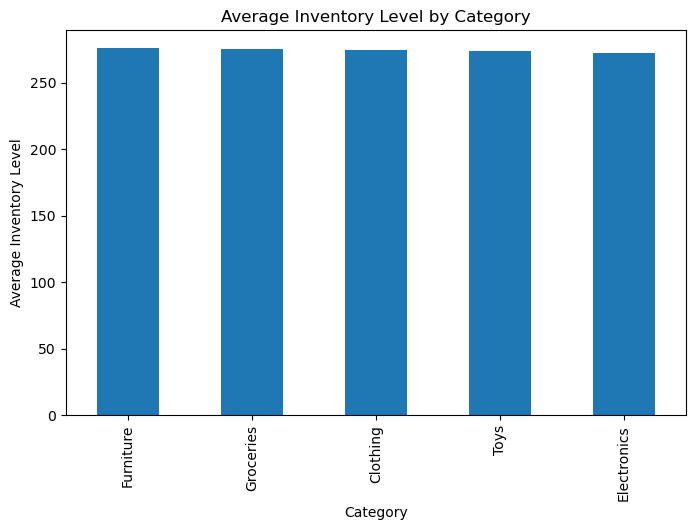

In [89]:
plt.figure(figsize=(8,5))

inventory_by_category.plot(kind="bar")

plt.title("Average Inventory Level by Category")
plt.xlabel("Category")
plt.ylabel("Average Inventory Level")

plt.show()

In [90]:
# Furniture has the highest average inventory level. But each category has about the same average.

In [91]:
# Average inventory levels are relatively consistent across all product categories, ranging from 272 to 276 units. This indicates a balanced inventory allocation strategy, with no category showing evidence of significant overstocking or understocking based on average inventory levels.

In [92]:
# 6. Inventory Turnover

In [93]:
inventory_turnover = (
    df.groupby("Product ID")
    .agg({
        "Units Sold": "sum",
        "Inventory Level": "mean"
    })
)

inventory_turnover["Inventory Turnover"] = (
    inventory_turnover["Units Sold"] /
    inventory_turnover["Inventory Level"]
)

inventory_turnover.head()

,Units Sold,Inventory Level,Inventory Turnover
Product ID,,,
P0001,498061,272.993981,1824.439493
P0002,487827,271.146101,1799.129686
P0003,493279,274.932695,1794.180936
P0004,495501,271.556498,1824.670018
P0005,503648,273.041860,1844.581630


In [94]:
# Inventory turnover is huge because of time period error in calculation

In [95]:
# CHecking dataset timeframe 

In [96]:
df["Date"].min(), df["Date"].max()

(Timestamp('2022-01-01 00:00:00'), Timestamp('2024-01-01 00:00:00'))

In [97]:
inventory_turnover = (
    df.groupby(["Product ID", "Store ID"])
    .agg({
        "Units Sold": "sum",
        "Inventory Level": "mean"
    })
)

inventory_turnover.head()

Units Sold  Inventory Level
Product ID Store ID                             
P0001      S001          100371       272.824897
           S002          105999       278.343365
           S003           94620       274.681259
           S004          101270       270.787962
           S005           95801       268.332421

In [98]:
# combine store and product for more accurate iventory turnover calculation

In [99]:
inventory_turnover["Annual Units Sold"] = (
    inventory_turnover["Units Sold"] / 2
)

In [100]:
inventory_turnover["Annual Inventory Turnover"] = (
    inventory_turnover["Annual Units Sold"] /
    inventory_turnover["Inventory Level"]
)

In [101]:
product_turnover = (
    inventory_turnover
    .groupby("Product ID")["Annual Inventory Turnover"]
    .mean()
    .sort_values(ascending=False)
)

product_turnover

Product ID
P0005    184.415707
P0015    183.491150
P0020    183.448465
P0016    183.255937
P0011    183.061120
P0014    182.684868
P0004    182.444031
P0001    182.419453
P0009    182.319139
P0013    181.959222
P0007    181.765054
P0006    181.705450
P0019    181.364233
P0018    180.716707
P0010    180.647683
P0012    180.417845
P0002    179.886604
P0017    179.874591
P0003    179.335152
P0008    179.120492
Name: Annual Inventory Turnover, dtype: float64

In [102]:
inventory_turnover.head()

Units Sold  Inventory Level  Annual Units Sold  \
Product ID Store ID                                                   
P0001      S001          100371       272.824897            50185.5   
           S002          105999       278.343365            52999.5   
           S003           94620       274.681259            47310.0   
           S004          101270       270.787962            50635.0   
           S005           95801       268.332421            47900.5   

                     Annual Inventory Turnover  
Product ID Store ID                             
P0001      S001                     183.947655  
           S002                     190.410502  
           S003                     172.235995  
           S004                     186.991326  
           S005                     178.511787

In [103]:
# Product-store inventory turnover was calculated to identify relative inventory movement. Higher turnover locations represent products with faster demand and may require more frequent replenishment.

In [104]:
# 10 fastest-moving product/store combinations

In [105]:
inventory_turnover.sort_values(
    "Annual Inventory Turnover",
    ascending=False
).head(10)

,,Units Sold,Inventory Level,Annual Units Sold,Annual Inventory Turnover
Product ID,Store ID,,,,
P0015,S005,109099,277.906977,54549.5,196.286904
P0020,S002,105343,276.309166,52671.5,190.625236
P0001,S002,105999,278.343365,52999.5,190.410502
P0005,S003,105408,277.566347,52704.0,189.878926
P0012,S002,102528,271.630643,51264.0,188.726866
P0017,S003,104566,277.150479,52283.0,188.644812
P0006,S004,103147,273.597811,51573.5,188.501143
P0013,S003,107479,285.261286,53739.5,188.386937
P0018,S002,102482,272.025992,51241.0,188.368029


In [106]:
# 10 slowest-moving combinations.

In [107]:
inventory_turnover.sort_values(
    "Annual Inventory Turnover"
).head(10)

,,Units Sold,Inventory Level,Annual Units Sold,Annual Inventory Turnover
Product ID,Store ID,,,,
P0003,S003,92556,270.206566,46278.0,171.268969
P0001,S003,94620,274.681259,47310.0,172.235995
P0003,S004,94436,272.023256,47218.0,173.580747
P0017,S001,99744,285.651163,49872.0,174.590572
P0006,S001,95522,272.953488,47761.0,174.978529
P0008,S002,94225,268.766074,47112.5,175.291841
P0002,S001,95789,272.663475,47894.5,175.654257
P0018,S004,94023,267.559508,47011.5,175.704838
P0012,S001,93854,266.763338,46927.0,175.912479


In [108]:
# Step 3. ABC ClASSIFICATION

In [109]:
# Purpose:Identify the most valuable products across the entire retail network.

In [110]:
#Class A 
#High-value products
#Top ~20% of products
#Generate ~70–80% of revenue
#Need:
#Frequent monitoring
#Accurate forecasting
#Strong replenishment control
#Class B Medium-value products
#Next ~30% of products
#Generate ~15–25% of revenue
#Need normal inventory management
#Class C
#Low-value products
#Remaining ~50% of products
#Generate small revenue contribution
#Need less frequent monitoring

In [111]:
# Step 1 Aggregate revenue by product

In [112]:
product_revenue = (
    df.groupby("Product ID")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

product_revenue

Product ID
P0020    28306192.40
P0011    28155025.56
P0016    28153328.38
P0014    28110375.77
P0005    27916663.02
P0013    27914863.65
P0015    27742249.64
P0009    27675549.22
P0007    27632505.00
P0001    27477692.24
P0004    27477122.68
P0018    27287304.88
P0010    27248852.75
P0006    27215738.62
P0019    27212252.42
P0017    27101072.39
P0003    27057650.52
P0008    26951354.38
P0002    26797736.64
P0012    26795354.75
Name: Revenue, dtype: float64

In [113]:
# products are extremely close in revenue because of simulated dataset

In [114]:
# Step 2: Calculate revenue percentage

In [115]:
revenue_percentage = (
    product_revenue /
    product_revenue.sum()
) * 100

revenue_percentage

Product ID
P0020    5.144440
P0011    5.116966
P0016    5.116658
P0014    5.108851
P0005    5.073645
P0013    5.073318
P0015    5.041947
P0009    5.029825
P0007    5.022002
P0001    4.993866
P0004    4.993762
P0018    4.959264
P0010    4.952276
P0006    4.946258
P0019    4.945624
P0017    4.925418
P0003    4.917526
P0008    4.898208
P0002    4.870289
P0012    4.869856
Name: Revenue, dtype: float64

In [116]:
# P0020 generates 5.144% of all revenue.

In [117]:
# Step 3 : Calculate cumulative percentage

In [118]:
cumulative_percentage = revenue_percentage.cumsum()

cumulative_percentage

Product ID
P0020      5.144440
P0011     10.261406
P0016     15.378063
P0014     20.486915
P0005     25.560560
P0013     30.633879
P0015     35.675826
P0009     40.705651
P0007     45.727653
P0001     50.721518
P0004     55.715281
P0018     60.674545
P0010     65.626821
P0006     70.573079
P0019     75.518703
P0017     80.444121
P0003     85.361647
P0008     90.259855
P0002     95.130144
P0012    100.000000
Name: Revenue, dtype: float64

In [119]:
# does not follow the classic 80/20 rule  since it is a simulated dataset" 

In [120]:
# Step 4 : perform the ABC classification

In [121]:
abc_analysis = pd.DataFrame({
    "Revenue": product_revenue,
    "Revenue %": revenue_percentage,
    "Cumulative %": cumulative_percentage
})


def classify_product(x):
    if x <= 80:
        return "A"
    elif x <= 95:
        return "B"
    else:
        return "C"


abc_analysis["ABC Classification"] = (
    abc_analysis["Cumulative %"]
    .apply(classify_product)
)


abc_analysis

,Revenue,Revenue %,Cumulative %,ABC Classification
Product ID,,,,
P0020,28306192.40,5.144440,5.144440,A
P0011,28155025.56,5.116966,10.261406,A
P0016,28153328.38,5.116658,15.378063,A
P0014,28110375.77,5.108851,20.486915,A
P0005,27916663.02,5.073645,25.560560,A
P0013,27914863.65,5.073318,30.633879,A
P0015,27742249.64,5.041947,35.675826,A
P0009,27675549.22,5.029825,40.705651,A
P0007,27632505.00,5.022002,45.727653,A


In [122]:
 # The ABC analysis revealed that revenue contribution is evenly distributed across products rather than concentrated among a small group of SKUs. Sixteen products were classified as Class A, indicating that most products require active inventory monitoring. This result differs from the traditional 80/20 pattern because the dataset contains relatively balanced product sales.

In [123]:
# Last step ABC summary visualization

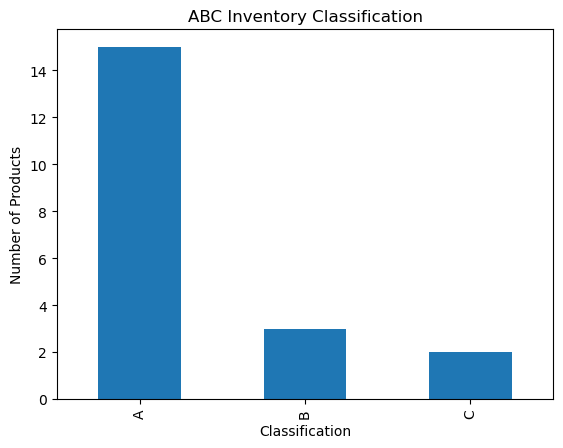

In [124]:
abc_analysis["ABC Classification"].value_counts().plot(
    kind="bar"
)

plt.title("ABC Inventory Classification")
plt.xlabel("Classification")
plt.ylabel("Number of Products")

plt.show()

In [125]:
# Two important metrics have now been completed : ABC Classification: and Inventory Turnover

In [126]:
# Step 4. demand forecasting model: predict units sold

In [127]:
# converting columns name from text to value"

In [128]:
# create a copy

In [129]:
model_df = df.copy()

In [130]:
model_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                73100 non-null  datetime64[ns]
 1   Store ID            73100 non-null  object        
 2   Product ID          73100 non-null  object        
 3   Category            73100 non-null  object        
 4   Region              73100 non-null  object        
 5   Inventory Level     73100 non-null  int64         
 6   Units Sold          73100 non-null  int64         
 7   Units Ordered       73100 non-null  int64         
 8   Demand Forecast     73100 non-null  float64       
 9   Price               73100 non-null  float64       
 10  Discount            73100 non-null  int64         
 11  Weather Condition   73100 non-null  object        
 12  Holiday/Promotion   73100 non-null  int64         
 13  Competitor Pricing  73100 non-null  float64   

In [131]:
# Create Time Features

In [132]:
# Day number 

In [133]:
model_df["Day"] = model_df["Date"].dt.day

In [134]:
# Week number 

In [135]:
model_df["Week"] = model_df["Date"].dt.isocalendar().week

In [136]:
df["Units Sold"].describe()

count    73100.000000
mean       136.464870
std        108.919406
min          0.000000
25%         49.000000
50%        107.000000
75%        203.000000
max        499.000000
Name: Units Sold, dtype: float64

In [137]:
# Data Preparation for Machine Learning

In [138]:
# Encoding

In [139]:
#Select Features and Target Variable
# X contains the input features used to predict demand.
# y is the target variable (Units Sold).

features = [
    "Inventory Level",
    "Units Ordered",
    "Price",
    "Discount",
    "Holiday/Promotion",
    "Competitor Pricing",
    "Category",
    "Region",
    "Weather Condition",
    "Seasonality",
    "Year",
    "Month",
    "Week",
    "Day"
]

X = model_df[features]

y = model_df["Units Sold"]

In [140]:
# Encode Categorical Variables
# Convert text variables into numerical (0/1) values for the model.

X = pd.get_dummies(X)

In [142]:
# Split the data
# separate: 80% data → model learns 20% data → test if it predicts correctly
# X_train and y_train are used to train the model.
# X_test and y_test are used to evaluate the model.

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [143]:
#Check

X_train.shape, X_test.shape

((58480, 27), (14620, 27))

In [144]:
# Build the Demand Forecasting Model

In [145]:
model_df.to_csv("inventory_model_ready.csv", index=False)

In [146]:
from sklearn.ensemble import RandomForestRegressor

In [147]:
# Train the Random Forest Model
# The model learns the relationship between the input features (X_train)
# and the target variable (y_train).

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [148]:
# Make Predictions
# Predict Units Sold for the unseen test data (X_test).
# Predictions are stored in y_pred.

y_pred = rf_model.predict(X_test)

In [149]:
# Check Predictions

y_pred[:10]

array([123.97, 118.69,  61.94, 182.94,  71.06, 193.69,  65.71, 262.41,
        68.48,  54.78])

In [150]:
# Evaluate the Model
# Compare the predicted values (y_pred) with the actual values (y_test)
# using MAE, RMSE, and R² Score.

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [151]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 69.63326128590971
RMSE: 89.32341626495337
R² Score: 0.3261065233326238


In [152]:
# Save the feature-engineered dataset
model_df.to_csv("inventory_model_ready.csv", index=False)

In [153]:
# Save actual and predicted demand
forecast_results = pd.DataFrame({
    "Actual Units Sold": y_test,
    "Predicted Units Sold": y_pred
})

forecast_results.to_csv("forecast_results.csv", index=False)